In [1]:
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

## Scenarios and parameter grids

In [2]:
# name : (dgp_names, model_short_names)
scenarios = {
    "tails": (
        ["iid_t6", "iid_skewt60_m05", "iid_skewt6_m05"],
        ["iid_normal", "iid_student_t", "iid_nonnormal"],
    ),
    "non4": (
        ["iid_t3", "iid_t6"],
        ["iid_student_t"],
    ),
    "serial": (
        ["ar1_06_normal", "ar1_m06_normal"],
        ["iid_normal", "ar1_normal"],
    ),
    "hetero_tails": (
        ["garch_normal"],
        ["iid_normal", "iid_nonnormal", "garch11"],
    ),
}

parameters = {
    "sr":    [0.5, 1.0, 1.5],
    "T":     [100, 500, 2_000],
    "n_sim": [1_000, 10_000, 50_000],
}

## Experiment registry

Each entry is an `ExperimentSpec`.  
Set `study_type` to one of:
- `StudyType.TWO_SIDED_COVERAGE` / `ONE_SIDED_COVERAGE`  — size / coverage runs  
- `StudyType.TWO_SIDED_POWER`    / `ONE_SIDED_POWER`     — power runs (requires `null_sr`)

In [3]:
N_SIM  = 10_000
N_JOBS = 8

experiments = {
    # ── two-sided coverage (original) ────────────────────────────────────────
    "tails": ExperimentSpec(
        scenario   = scenarios["tails"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        sr_default = 0.5,
        n_default  = N_SIM,
        n_jobs     = N_JOBS,
    ),
    "tails_th": ExperimentSpec(
        scenario   = scenarios["tails"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        sr_default = 0.5,
        th_moments = True,
        n_default  = N_SIM,
        n_jobs     = N_JOBS,
    ),
    "non4": ExperimentSpec(
        scenario   = scenarios["non4"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        n_default  = N_SIM,
        n_jobs     = N_JOBS,
    ),
    "serial": ExperimentSpec(
        scenario   = scenarios["serial"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        n_default  = N_SIM,
        n_jobs     = N_JOBS,
    ),
    "hetero_tails": ExperimentSpec(
        scenario   = scenarios["hetero_tails"],
        param_name = "sr",
        param_values = parameters["sr"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        th_moments = True,
        n_default  = N_SIM,
        n_jobs     = N_JOBS,
    ),

    # ── one-sided coverage (size of one-sided test) ───────────────────────────
    "tails_1s": ExperimentSpec(
        scenario   = scenarios["tails"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        n_default  = N_SIM,
        n_jobs     = N_JOBS,
    ),
    "serial_1s": ExperimentSpec(
        scenario   = scenarios["serial"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        n_default  = N_SIM,
        n_jobs     = N_JOBS,
    ),

    # ── two-sided power  (DGP at θ=0.5, null at θ₀=0.0) ─────────────────────
    "tails_2s_power": ExperimentSpec(
        scenario   = scenarios["tails"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_POWER,
        null_sr    = 0.0,          # H₀: SR = 0
        sr_default = 0.5,          # true SR under H₁
        n_default  = N_SIM,
        n_jobs     = N_JOBS,
    ),
    "serial_2s_power": ExperimentSpec(
        scenario   = scenarios["serial"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_POWER,
        null_sr    = 0.0,
        sr_default = 0.5,
        n_default  = N_SIM,
        n_jobs     = N_JOBS,
    ),

    # ── one-sided power  (DGP at θ=0.5, null at θ₀=0.0) ─────────────────────
    "tails_1s_power": ExperimentSpec(
        scenario   = scenarios["tails"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.ONE_SIDED_POWER,
        null_sr    = 0.0,
        sr_default = 0.5,
        n_default  = N_SIM,
        n_jobs     = N_JOBS,
    ),
    "serial_1s_power": ExperimentSpec(
        scenario   = scenarios["serial"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.ONE_SIDED_POWER,
        null_sr    = 0.0,
        sr_default = 0.5,
        n_default  = N_SIM,
        n_jobs     = N_JOBS,
    ),
}

---
## EXECUTION

In [4]:
# ── coverage / size runs ──────────────────────────────────────────────────────
run_selected_configs(
    experiments,
    selected_experiments=[
        "tails",
        "tails_th",
        # "non4",
        # "serial",
        # "hetero_tails",
        # "tails_1s",
        # "serial_1s",
    ],
)


  Experiment: tails
  [1/3]  T=100  (TWO_SIDED_COVERAGE)
  [2/3]  T=500  (TWO_SIDED_COVERAGE)
  [3/3]  T=2000  (TWO_SIDED_COVERAGE)

  Experiment: tails_th
  [1/3]  T=100  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [2/3]  T=500  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [3/3]  T=2000  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE


In [ ]:
# ── power runs ────────────────────────────────────────────────────────────────
run_selected_configs(
    experiments,
    selected_experiments=[
        "tails_2s_power",
        # "tails_1s_power",
        # "serial_2s_power",
        # "serial_1s_power",
    ],
)

---
## VISUALIZATION — Coverage / Size

=== TWO_SIDED_COVERAGE — T sweep ===
   T        dgp_name    avar_model  nominal  coverage     bias     rmse
 100          iid_t6    iid_normal     0.95    0.9378 0.008720 0.113578
 100          iid_t6 iid_student_t     0.95    0.9460 0.008720 0.113578
 100          iid_t6 iid_nonnormal     0.95    0.9400 0.008720 0.113578
 100 iid_skewt60_m05    iid_normal     0.95    0.9058 0.007759 0.126083
 100 iid_skewt60_m05 iid_student_t     0.95    0.9101 0.007759 0.126083
 100 iid_skewt60_m05 iid_nonnormal     0.95    0.9460 0.007759 0.126083
 100  iid_skewt6_m05    iid_normal     0.95    0.8544 0.020904 0.148297
 100  iid_skewt6_m05 iid_student_t     0.95    0.8749 0.020904 0.148297
 100  iid_skewt6_m05 iid_nonnormal     0.95    0.9289 0.020904 0.148297
 500          iid_t6    iid_normal     0.95    0.9337 0.002115 0.051063
 500          iid_t6 iid_student_t     0.95    0.9485 0.002115 0.051063
 500          iid_t6 iid_nonnormal     0.95    0.9477 0.002115 0.051063
 500 iid_skewt60_m05    iid

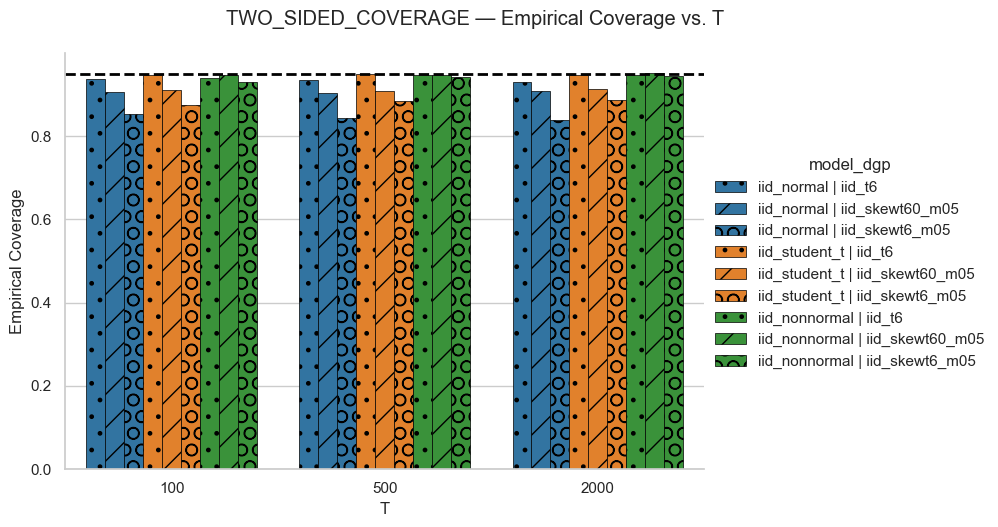

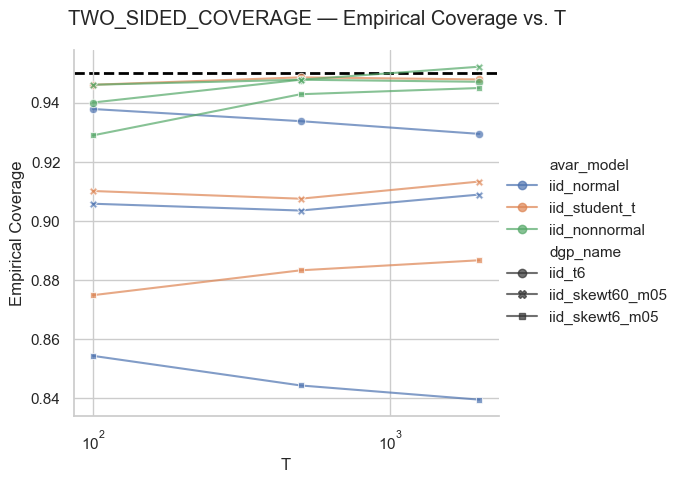

In [5]:
run_analysis(experiments, "tails",       alpha=0.05)

=== TWO_SIDED_COVERAGE — T sweep ===
   T        dgp_name    avar_model  nominal  coverage     bias     rmse
 100          iid_t6    iid_normal     0.95    0.9378 0.008720 0.113578
 100          iid_t6 iid_student_t     0.95    0.9586 0.008720 0.113578
 100          iid_t6 iid_nonnormal     0.95    0.9586 0.008720 0.113578
 100 iid_skewt60_m05    iid_normal     0.95    0.9058 0.007759 0.126083
 100 iid_skewt60_m05 iid_student_t     0.95    0.9121 0.007759 0.126083
 100 iid_skewt60_m05 iid_nonnormal     0.95    0.9500 0.007759 0.126083
 100  iid_skewt6_m05    iid_normal     0.95    0.8544 0.020904 0.148297
 100  iid_skewt6_m05 iid_student_t     0.95    0.9185 0.020904 0.148297
 100  iid_skewt6_m05 iid_nonnormal     0.95    0.9635 0.020904 0.148297
 500          iid_t6    iid_normal     0.95    0.9337 0.002115 0.051063
 500          iid_t6 iid_student_t     0.95    0.9525 0.002115 0.051063
 500          iid_t6 iid_nonnormal     0.95    0.9525 0.002115 0.051063
 500 iid_skewt60_m05    iid

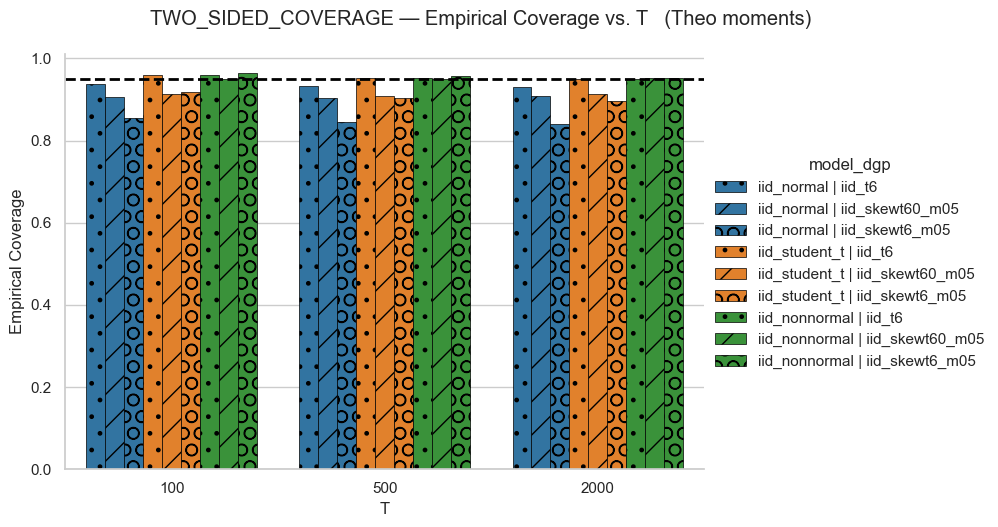

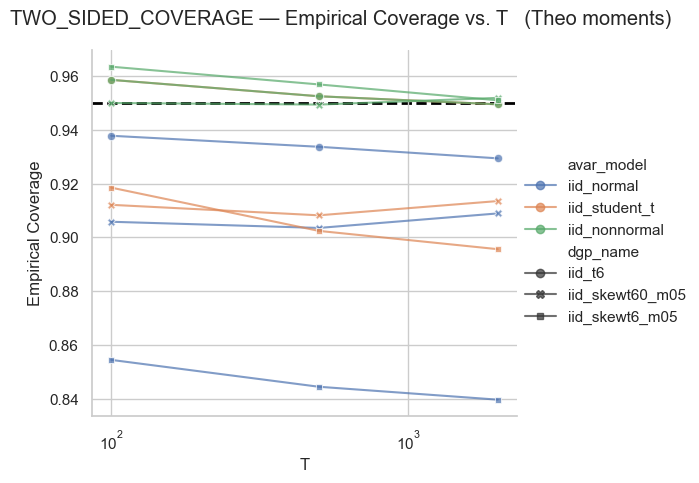

In [6]:
run_analysis(experiments, "tails_th",    alpha=0.05)

In [ ]:
run_analysis(experiments, "serial",      alpha=0.05)

In [ ]:
run_analysis(experiments, "hetero_tails", alpha=0.05)

In [ ]:
run_analysis(experiments, "tails_1s",    alpha=0.05)

---
## VISUALIZATION — Power

In [ ]:
run_analysis(experiments, "tails_2s_power", alpha=0.05)

In [ ]:
run_analysis(experiments, "tails_1s_power", alpha=0.05)

In [ ]:
run_analysis(experiments, "serial_2s_power", alpha=0.05)